In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
%reload_ext autoreload
import csv
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# remove RankWarning
import warnings
warnings.simplefilter('ignore', np.RankWarning)

In [3]:
# define plotting function for loss, loss_h, loss_c, l2 pose loss, yaw error in one plot
def plot_metric(df, title):
    
    metric = ["loss", "loss_h", "loss_c", "trans_l2_m", "yaw_err_deg"]
    fig, ax = plt.subplots(2, 3, figsize=(12, 6))
    
    for m in metric:
        last_mean = df[m][-500:].mean()
        sns.scatterplot(data=df, x=df.index, y=m, label="Final Mean: {:.4f}".format(last_mean), s=1, ax=ax.flatten()[metric.index(m)])
        # trend line
        z = np.polyfit(df.index, df[m],15)
        p = np.poly1d(z)
        ax.flatten()[metric.index(m)].plot(df.index, p(df.index), "r--", label='Trend Line')
        ax.flatten()[metric.index(m)].set_xlabel('Iterations')
        ax.flatten()[metric.index(m)].set_ylim([0, df[m].max()*1.1])
        ax.flatten()[metric.index(m)].set_ylabel(m)
        ax.flatten()[metric.index(m)].set_title(m+' over Training Iterations')
        ax.flatten()[metric.index(m)].legend()
        ax.flatten()[metric.index(m)].grid()
    fig.suptitle(title)
    fig.tight_layout()
    fig.show()

# Latest training

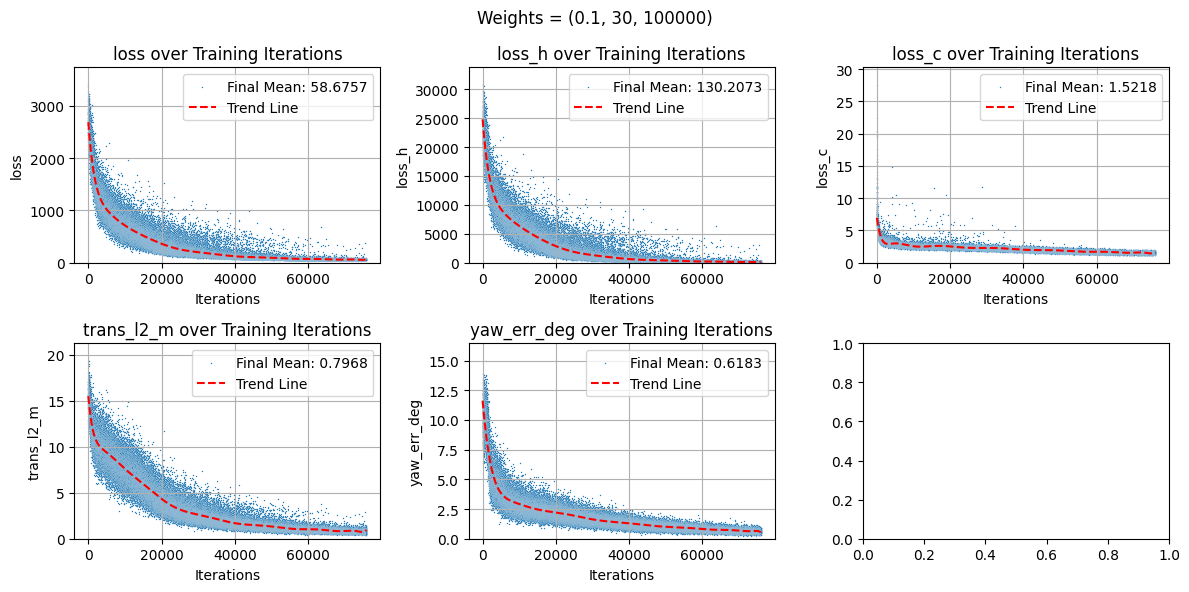

In [45]:
df = pd.read_csv("metrics/train/2026_01_09_14_37_09.csv")
plot_metric(df, "Weights = (0.1, 30, 100000)")

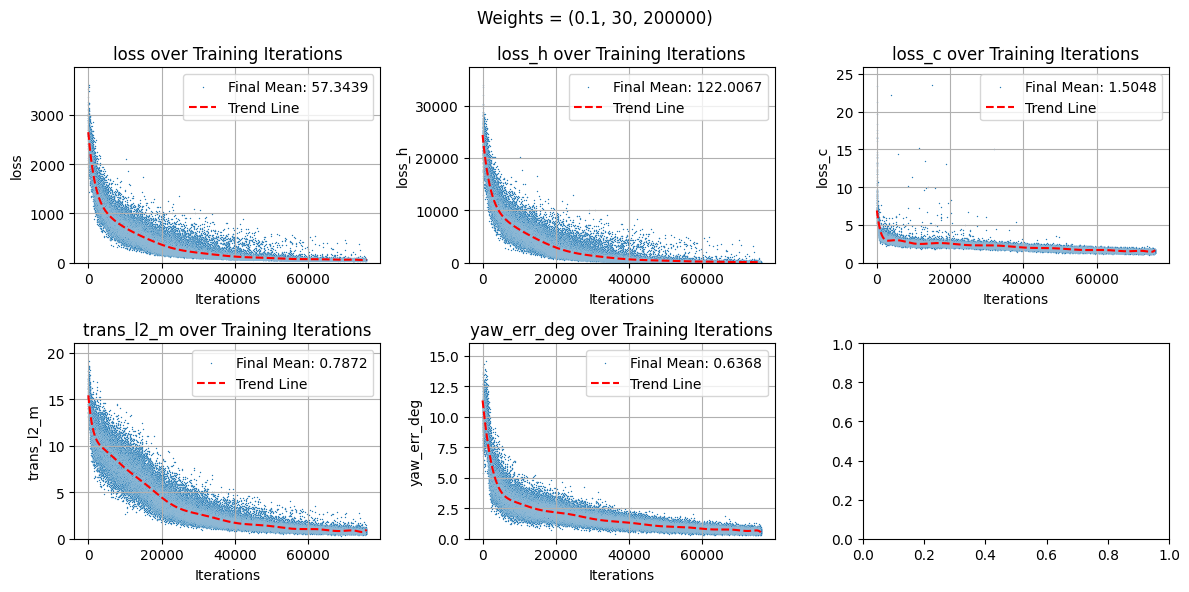

In [46]:
df = pd.read_csv("metrics/train/2026_01_09_14_36_50.csv")
plot_metric(df, "Weights = (0.1, 30, 200000)")

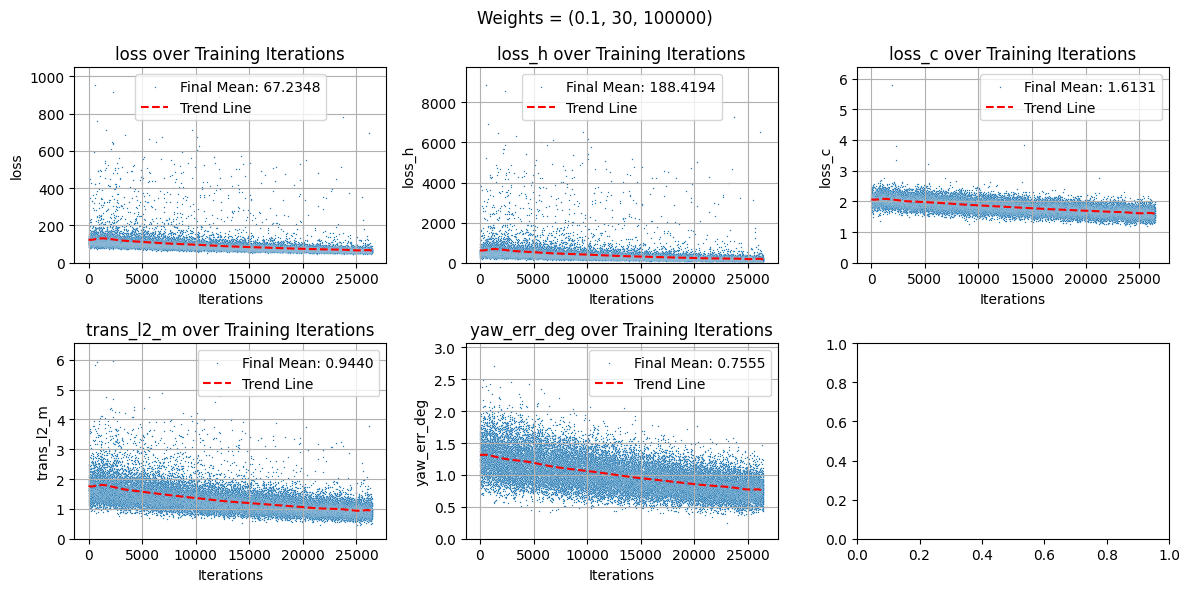

In [47]:
df = pd.read_csv("metrics/train/2026_01_11_17_52_20.csv")
plot_metric(df, "Weights = (0.1, 30, 100000)")

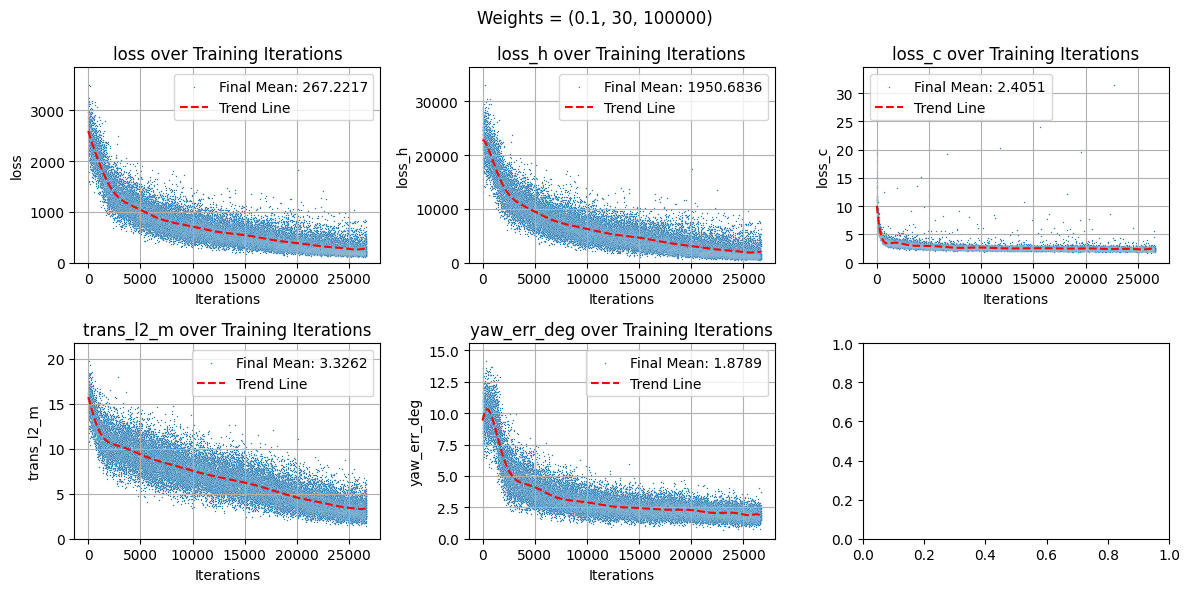

In [48]:
df = pd.read_csv("metrics/train/2026_01_11_17_36_19.csv")
plot_metric(df, "Weights = (0.1, 30, 100000)")

# Previous, faulty training

I had introduced the translation shift in the lidar points and I believe the model learned to center the points rather that leanring localization

In [16]:
fp = "metrics/train/2025_12_27_0.csv"

df = pd.read_csv(fp)

# Count how many times we've seen each (epoch, batch) so far
df["_occurrence"] = df.groupby(["epoch", "batch"]).cumcount()

# Split into two dataframes
df_model_1 = df[df["_occurrence"] == 0].drop(columns="_occurrence").reset_index(drop=True)
df_model_2 = df[df["_occurrence"] == 1].drop(columns="_occurrence").reset_index(drop=True)

print(len(df_model_1), len(df_model_2), "/", len(df))


69222 30439 / 99661


/tmp/ipykernel_3753663/280869166.py:11: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(df.index, df[m],15)
/tmp/ipykernel_3753663/280869166.py:11: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(df.index, df[m],15)
/tmp/ipykernel_3753663/280869166.py:11: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(df.index, df[m],15)
/tmp/ipykernel_3753663/280869166.py:11: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(df.index, df[m],15)
/tmp/ipykernel_3753663/280869166.py:11: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(df.index, df[m],15)


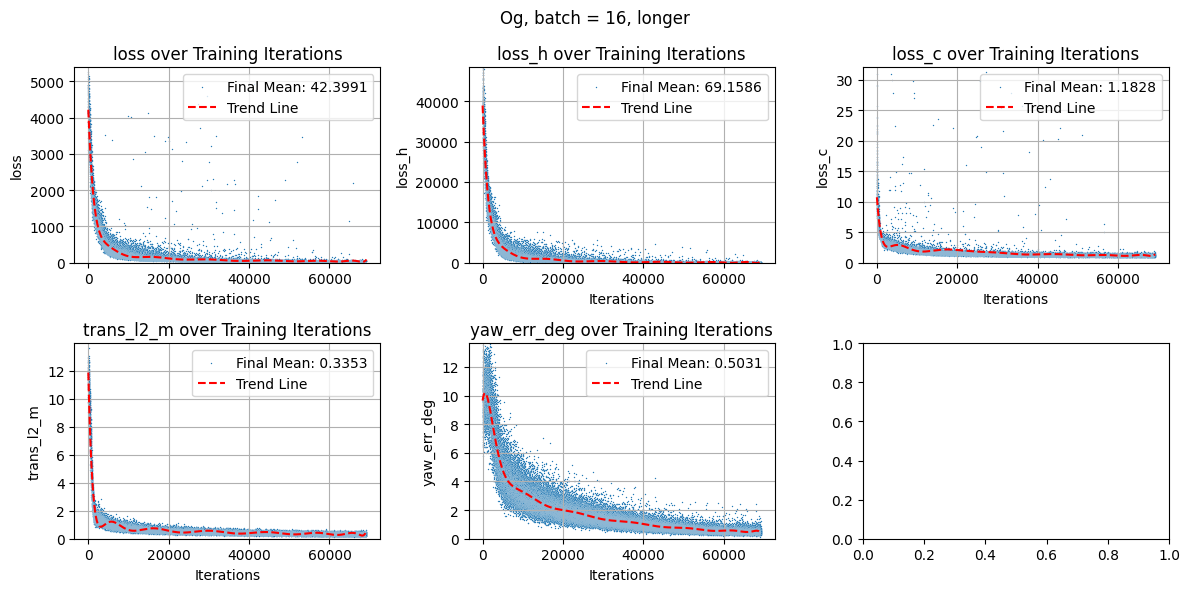

In [17]:
plot_metric(df_model_1, 'Og, batch = 16, longer')

# Validation

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
fp  = "metrics/val/2026_01_12_13_18_17_hcnet_zod_eval.csv"
df = pd.read_csv(fp)


In [15]:
df.loc[df.meters_l2 > 45]

,scene_name,frame_name,iteration,meters_l2,yaw_err_deg,time_ms
442,7,2210,27,51.1446,0.4334,42.21
516,1,285,32,45.1198,3.1307,27.38
1447,2,1235,90,48.4267,5.0320,40.03


In [16]:
df.iloc[ df.meters_l2.argmax()]

scene_name        7.0000
frame_name     2210.0000
iteration        27.0000
meters_l2        51.1446
yaw_err_deg       0.4334
time_ms          42.2100
Name: 442, dtype: float64

In [20]:
df.loc[ df.meters_l2 > df.meters_l2.max()*0.88]

,scene_name,frame_name,iteration,meters_l2,yaw_err_deg,time_ms
442,7,2210,27,51.1446,0.4334,42.21
516,1,285,32,45.1198,3.1307,27.38
1447,2,1235,90,48.4267,5.0320,40.03


In [16]:
df.iloc[ df.yaw_err_deg.argmax()]

scene_name        5.0000
frame_name     1399.0000
iteration       211.0000
meters_l2         0.9402
yaw_err_deg      42.1209
time_ms          21.6600
Name: 6781, dtype: float64

In [21]:
df.loc[ df.yaw_err_deg > df.yaw_err_deg.max()*0.935]

,scene_name,frame_name,iteration,meters_l2,yaw_err_deg,time_ms
312,7,1560,19,39.7188,39.8525,36.38
1344,2,720,84,4.0938,38.1009,34.94
1346,2,730,84,12.7846,38.4511,34.94
1393,2,965,87,36.4470,39.8200,54.03


In [32]:
df.loc[ df.meters_l2 < df.meters_l2.min()*2]

,scene_name,frame_name,iteration,meters_l2,yaw_err_deg,time_ms
655,1,985,40,0.1711,5.5437,47.00
1199,28,735,74,0.3390,4.5843,33.74
1270,2,350,79,0.3137,8.7099,31.78
1315,2,575,82,0.2855,3.9807,37.53


In [30]:
df.loc[ df.yaw_err_deg < df.yaw_err_deg.min()*60]

,scene_name,frame_name,iteration,meters_l2,yaw_err_deg,time_ms
140,7,700,8,15.5107,0.0038,45.02
191,7,955,11,8.3320,0.0236,36.57
575,1,580,35,7.4954,0.0164,40.22
1158,28,530,72,12.3538,0.0004,25.08


<Axes: xlabel='None', ylabel='meters_l2'>

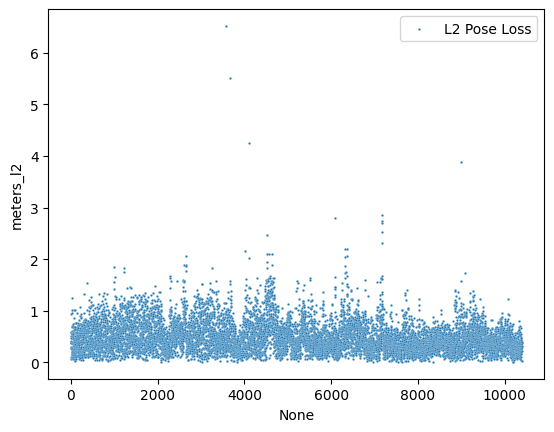

In [5]:
import seaborn as sns
sns.scatterplot(data=df, x=df.index, y='meters_l2', label='L2 Pose Loss', s=3)

<Axes: xlabel='None', ylabel='yaw_err_deg'>

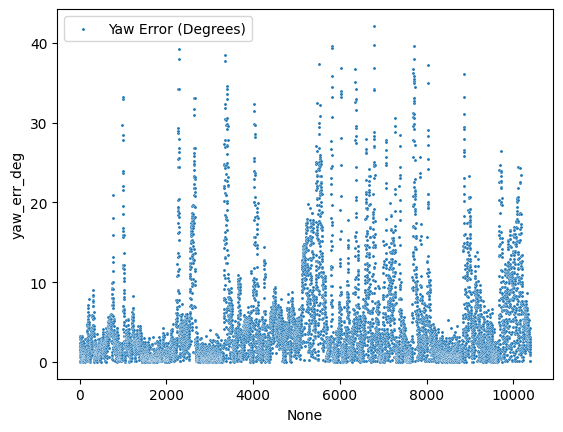

In [42]:
sns.scatterplot(data=df, x=df.index, y='yaw_err_deg', label='Yaw Error (Degrees)', s=5)

/tmp/ipykernel_2324965/4123043644.py:2: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(df.index[700:900], df['yaw_err_deg'][700:900],20)


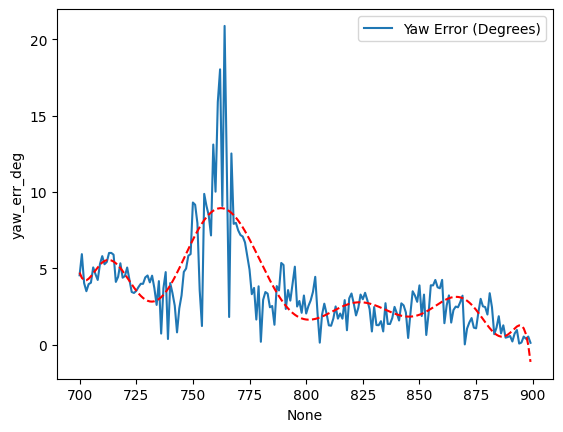

In [50]:
sns.lineplot(data=df.iloc[700:900], x=df.index[700:900], y='yaw_err_deg', label='Yaw Error (Degrees)')#, s=5)
z = np.polyfit(df.index[700:900], df['yaw_err_deg'][700:900],20)
p = np.poly1d(z)
plt.plot(df.index[700:900], p(df.index[700:900]), "r--", label='Trend Line')


{1: 0.25286250360819784, 2: 0.4331761762724911, 5: 0.7313576445684595, 10: 0.8765515250649476, 20: 0.965842393918984}


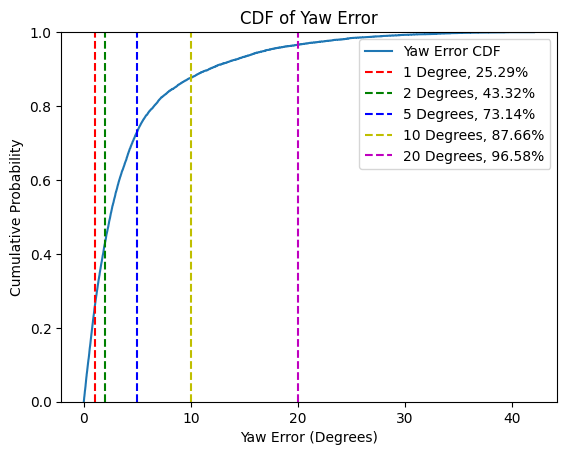

In [12]:
# compute cfd intersection points at 1,2,5,10 degrees
def compute_cdf_intersections(data, thresholds):
    sorted_data = np.sort(data)
    cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    intersections = {}
    for threshold in thresholds:
        idx = np.searchsorted(sorted_data, threshold, side='right') - 1
        if idx >= 0:
            intersections[threshold] = cdf[idx]
        else:
            intersections[threshold] = 0.0
    return intersections
thresholds = [1, 2, 5, 10, 20]
intersections = compute_cdf_intersections(df['yaw_err_deg'], thresholds)
print(intersections)

# cdf plot for yaw error with 1,2, 5, 10 degree lines
sns.ecdfplot(data=df, x='yaw_err_deg', label='Yaw Error CDF')
plt.axvline(x=1, color='r', linestyle='--', label=f'1 Degree, {intersections[1]*100:.2f}%')
plt.axvline(x=2, color='g', linestyle='--', label=f'2 Degrees, {intersections[2]*100:.2f}%')
plt.axvline(x=5, color='b', linestyle='--', label=f'5 Degrees, {intersections[5]*100:.2f}%')
plt.axvline(x=10, color='y', linestyle='--', label=f'10 Degrees, {intersections[10]*100:.2f}%')
plt.axvline(x=20, color='m', linestyle='--', label=f'20 Degrees, {intersections[20]*100:.2f}%')
plt.xlabel('Yaw Error (Degrees)')
plt.ylabel('Cumulative Probability')
plt.title('CDF of Yaw Error')
plt.legend()

{1: 0.9341864716636198, 2: 0.9979794092177428, 5: 0.9998075627826422}


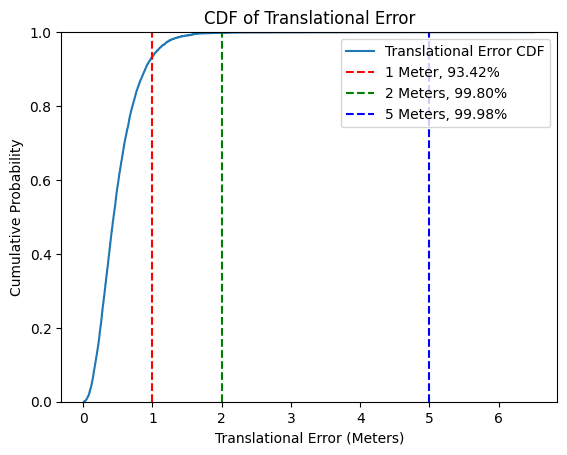

In [13]:
# compute cfd intersection points at 1,2,5,10 degrees
thresholds = [1, 2, 5]
intersections = compute_cdf_intersections(df['meters_l2'], thresholds)
print(intersections)

# cdf plot for translational error with 1,2, 5 meter lines
sns.ecdfplot(data=df, x='meters_l2', label='Translational Error CDF')
plt.axvline(x=1, color='r', linestyle='--', label=f'1 Meter, {intersections[1]*100:.2f}%')
plt.axvline(x=2, color='g', linestyle='--', label=f'2 Meters, {intersections[2]*100:.2f}%')
plt.axvline(x=5, color='b', linestyle='--', label=f'5 Meters, {intersections[5]*100:.2f}%')
plt.xlabel('Translational Error (Meters)')
plt.ylabel('Cumulative Probability')
plt.title('CDF of Translational Error')
plt.legend()

Text(0.5, 1.0, 'Histogram of Translational Errors')

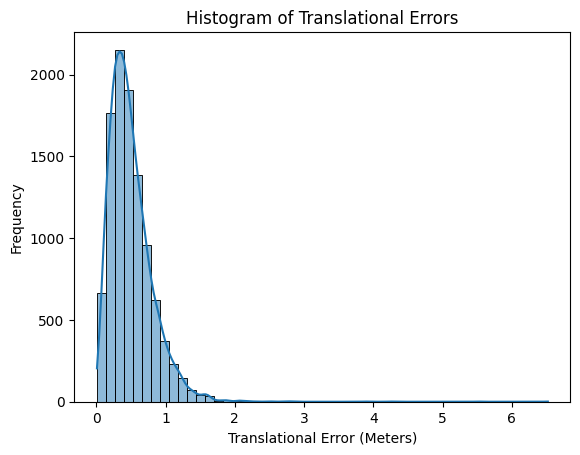

In [ ]:
# Error histogram (distribution of errors)
sns.histplot(data=df, x='meters_l2', bins=50, kde=True)
plt.xlabel('Translational Error (Meters)')
plt.ylabel('Frequency')
plt.title('Histogram of Translational Errors')

Text(0.5, 1.0, 'Histogram of Yaw Errors')

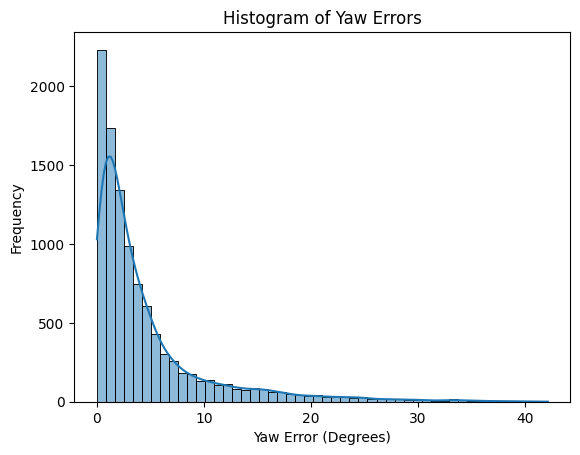

In [10]:
# Error histogram (distribution of errors)
sns.histplot(data=df, x='yaw_err_deg', bins=50, kde=True)
plt.xlabel('Yaw Error (Degrees)')
plt.ylabel('Frequency')
plt.title('Histogram of Yaw Errors')

# CDFs

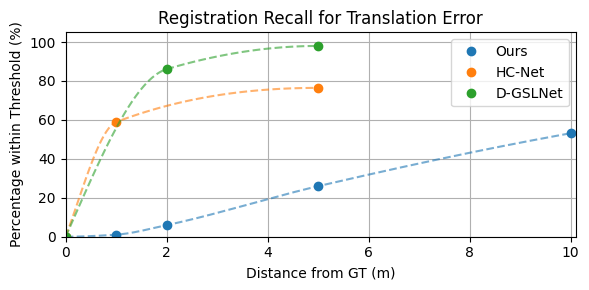

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

# Updated data
trans_zod = [[0,1,2,5,10], [0, 1.06, 5.96, 25.97, 53.17]]
trans_HC = [[0,1,5], [0, 58.93, 76.46]]
trans_DG = [[0,2,5], [0, 86.08, 98.0]]

# Interpolation points
xnew = np.linspace(0, 10, 200)

# Function to create smooth CDF-like curve
def smooth_cdf(data, x_val):
    x, y = data
    interp = PchipInterpolator(x, y)  # preserves monotonicity
    return interp(x_val)


# Define colors for each dataset
colors = {
    'ZOD': 'tab:blue',
    'HC': 'tab:orange',
    'DG': 'tab:green'
}

plt.figure(figsize=(6, 3))


# Plot raw points and smooth curves with consistent colors
plt.plot(trans_zod[0], trans_zod[1], 'o', color=colors['ZOD'], label='Ours')
plt.plot(xnew, smooth_cdf(trans_zod, xnew), '--', color=colors['ZOD'], alpha=0.6)

plt.plot(trans_HC[0], trans_HC[1], 'o', color=colors['HC'], label='HC-Net')
plt.plot(xnew[:100], smooth_cdf(trans_HC, xnew[:100]), '--', color=colors['HC'], alpha=0.6)

plt.plot(trans_DG[0], trans_DG[1], 'o', color=colors['DG'], label='D-GSLNet')
plt.plot(xnew[:100], smooth_cdf(trans_DG, xnew[:100]), '--', color=colors['DG'], alpha=0.6)

# Labels and formatting
plt.xlabel('Distance from GT (m)')
plt.ylabel('Percentage within Threshold (%)')
plt.ylim(0, 105)
plt.xlim(0, 10.1)
plt.title('Registration Recall for Translation Error')
plt.grid(True)
plt.legend()
plt.tight_layout()


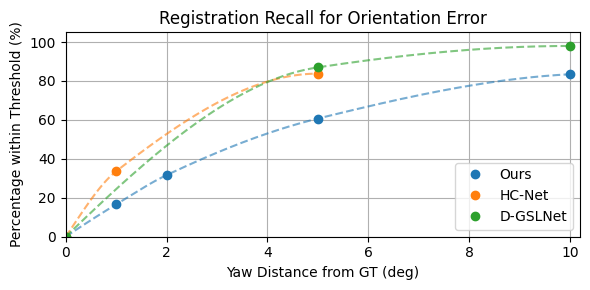

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

ori_zod = [[0,1,2,5,10],[0, 16.60, 31.63, 60.70, 83.46]]
ori_HC = [[0,1,5],[0, 33.58 , 83.78]]
ori_DG = [[0,5,10],[0, 87.0, 98.0]]

# Interpolation points
xnew = np.linspace(0, 10.1, 200)

# Function to create smooth CDF-like curve
def smooth_cdf(data):
    x, y = data
    interp = PchipInterpolator(x, y)  # preserves monotonicity
    return interp(xnew)

# Define colors for each dataset
colors = {
    'ZOD': 'tab:blue',
    'HC': 'tab:orange',
    'DG': 'tab:green'
}

plt.figure(figsize=(6, 3))


# Plot raw points and smooth curves with consistent colors
plt.plot(ori_zod[0], ori_zod[1], 'o', color=colors['ZOD'], label='Ours')
plt.plot(xnew, smooth_cdf(ori_zod), '--', color=colors['ZOD'], alpha=0.6)

plt.plot(ori_HC[0], ori_HC[1], 'o', color=colors['HC'], label='HC-Net')
plt.plot(xnew[:100], smooth_cdf(ori_HC)[:100], '--', color=colors['HC'], alpha=0.6) 
plt.plot(ori_DG[0], ori_DG[1], 'o', color=colors['DG'], label='D-GSLNet')
plt.plot(xnew, smooth_cdf(ori_DG), '--', color=colors['DG'], alpha=0.6)

# Labels and formatting
plt.xlabel('Yaw Distance from GT (deg)')
plt.ylabel('Percentage within Threshold (%)')
plt.ylim(0, 105)
plt.xlim(0, 10.2)
plt.title('Registration Recall for Orientation Error')
plt.grid(True)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()
